


                HEART DISEASE PREDICTION USING ANN
                           
           Artificial Neural Network Implementation Guide
                                        



This notebook provides a complete guide to building an Artificial Neural
Network for predicting heart disease. Each step includes detailed explanations,
visualizations, and best practices.


Date: 30 july 2026

Dataset: Heart Disease Prediction (Kaggle)

# STEP 1: IMPORT NECESSARY LIBRARIES

EXPLANATION: Libraries are packages that contain pre-written code for
specific tasks. We import them to use their functions and classes.


📚 Libraries We'll Use:
  • pandas: Data manipulation and analysis

  • numpy: Numerical operations and arrays

  • matplotlib & seaborn: Data visualization

  • scikit-learn: Machine learning preprocessing and metrics
  
  • tensorflow/keras: Deep learning framework for neural networks

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# STEP 2: LOAD AND EXPLORE THE DATASET

EXPLANATION: Data exploration is the first critical step in machine learning.
We need to understand:

  • Dataset shape (rows, columns)

  • Data types (numeric, categorical)

  • Missing values

  • Statistical properties (mean, std, min, max)
  
  • Target variable distribution

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ANN_assignment2_/Heart_Disease_Prediction.csv')

In [ ]:
df.shape

(270, 14)

In [ ]:
df.shape[0]

270

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [ ]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


# STEP 3: DATA VISUALIZATION AND ANALYSIS

EXPLANATION: Visualization helps us understand data patterns visually.
We'll create:

  • Distribution plots: Show how features are distributed

  • Correlation heatmap: Show relationships between features
  
  • Target variable distribution: Show class balance

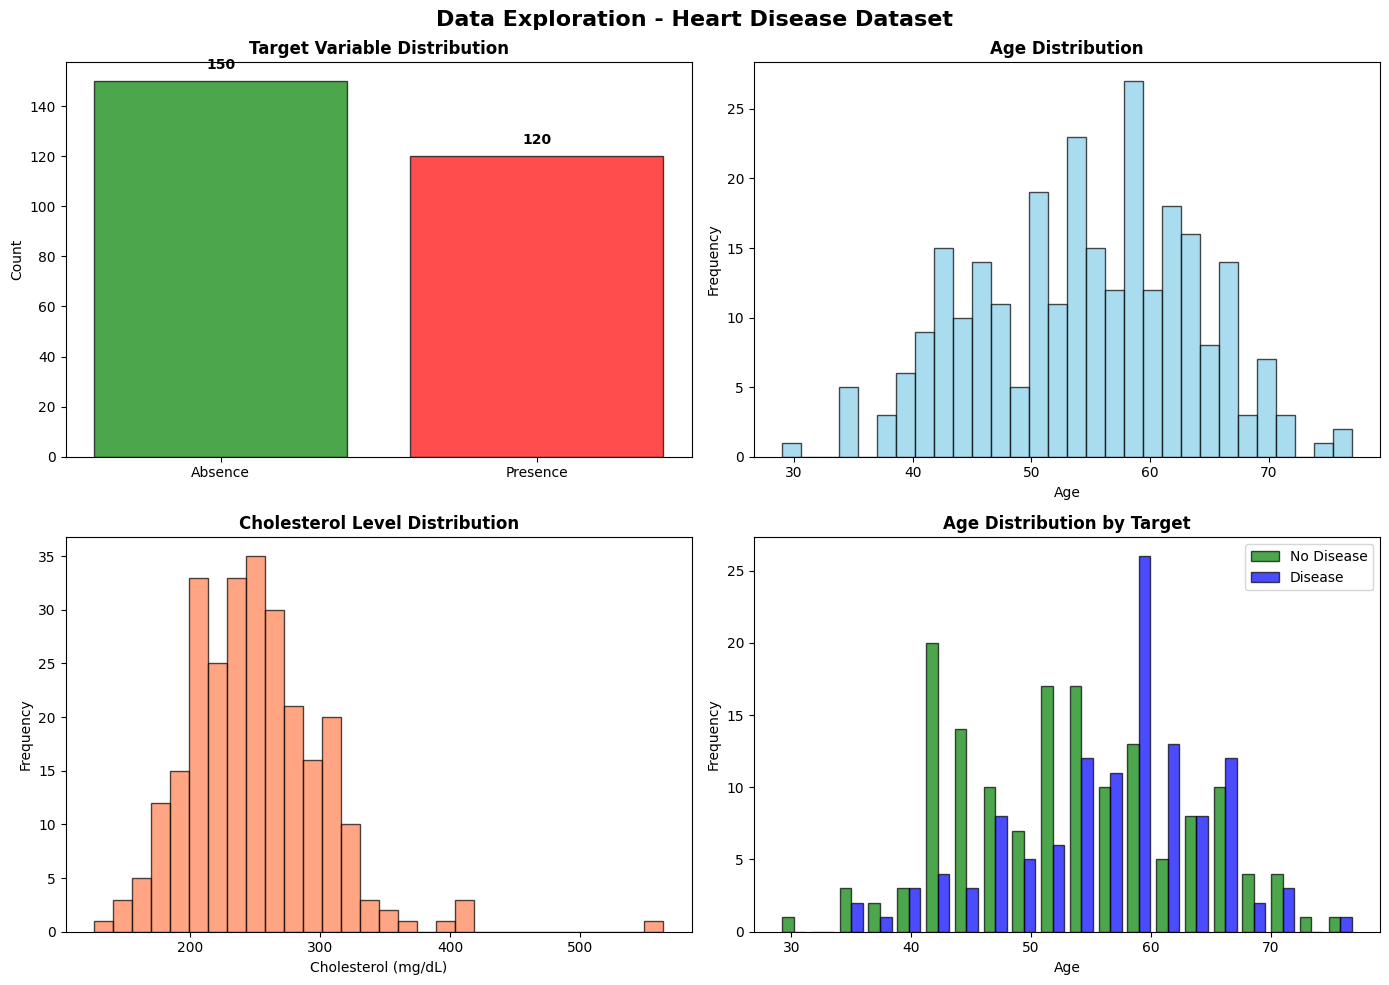

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Data Exploration - Heart Disease Dataset', fontsize=16, fontweight='bold')

# Plot 1: Target variable distribution
ax1 = axes[0, 0]
target_counts = df['Heart Disease'].value_counts()
colors = ['Green', 'Red']  # Green for No Disease, Red for Disease
ax1.bar(['Absence', 'Presence'], target_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_title('Target Variable Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Age distribution
ax2 = axes[0, 1]
ax2.hist(df['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax2.set_title('Age Distribution', fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')

# Plot 3: Cholesterol distribution
ax3 = axes[1, 0]
ax3.hist(df['Cholesterol'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax3.set_title('Cholesterol Level Distribution', fontweight='bold')
ax3.set_xlabel('Cholesterol (mg/dL)')
ax3.set_ylabel('Frequency')

# Plot 4: Target by Age
ax4 = axes[1, 1]
no_disease = df[df['Heart Disease'] == 'Absence']['Age']
disease = df[df['Heart Disease'] == 'Presence']['Age']
ax4.hist([no_disease, disease], bins=20, label=['No Disease', 'Disease'],
         color=['green', 'blue'], alpha=0.7, edgecolor='black')
ax4.set_title('Age Distribution by Target', fontweight='bold')
ax4.set_xlabel('Age')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

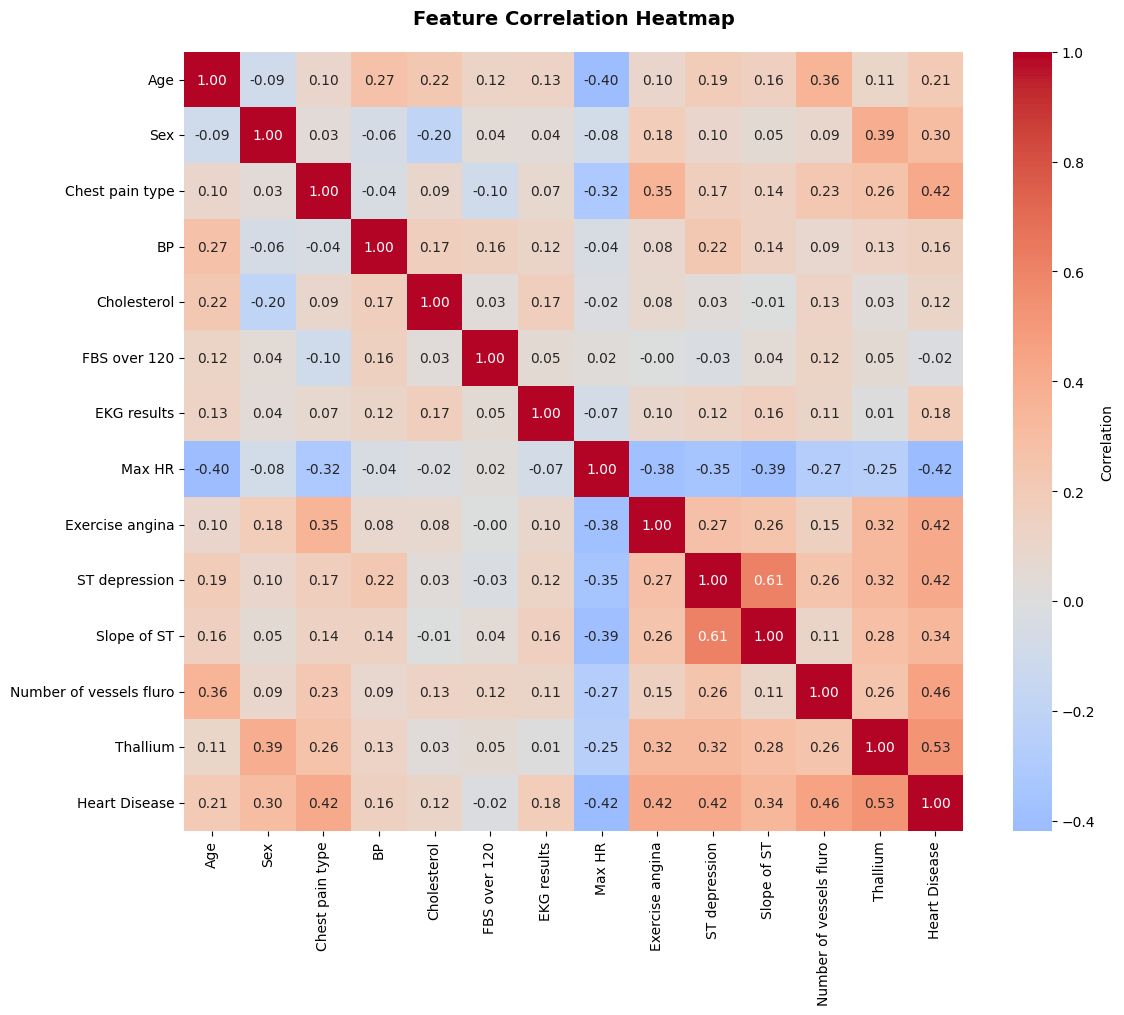

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Convert 'Heart Disease' column to numerical for correlation calculation
df_encoded = df.copy()
df_encoded['Heart Disease'] = df_encoded['Heart Disease'].map({'Absence': 0, 'Presence': 1})

correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# STEP 4: DATA PREPROCESSING AND FEATURE ENGINEERING

EXPLANATION: Preprocessing prepares data for neural network training:

🔧 Key Preprocessing Steps:
  1. Handling Missing Values: Fill or remove null values
  
  2. Identifying Feature Types: Separate numeric and categorical features

  3. Encoding Categorical Variables: Convert text to numbers

  4. Feature Scaling/Normalization: Standardize feature ranges

     - Why? Neural networks perform better when all features have similar scales

  5. Train-Test Split: Divide data for training and evaluation.

In [ ]:
# Step 4.1: Handle missing values (if any)
print("\n4.1 Handling Missing Values:")
if df.isnull().sum().sum() == 0:
    print("   ✓ No missing values found!")
else:
    print("   Handling missing values...")
    df = df.dropna()
    print("   ✓ Missing values removed!")


4.1 Handling Missing Values:
   ✓ No missing values found!


In [ ]:
# Step 4.2: Separate features and target
print("\n4.2 Separating Features and Target:")

X = df.drop('Heart Disease', axis=1)  # Features (all columns except 'Heart Disease')
y = df['Heart Disease'].map({'Absence': 0, 'Presence': 1}) # Target (encoded numerically)

print(f"   ✓ Features shape: {X.shape}")
print(f"   ✓ Target shape: {y.shape}")


4.2 Separating Features and Target:
   ✓ Features shape: (270, 13)
   ✓ Target shape: (270,)


WHY TRAIN-TEST SPLIT?
- Training set (80%): Used to train the neural network

- Testing set (20%): Used to evaluate model performance on
 unseen data

- This prevents overfitting (memorizing data instead of learning patterns)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

WHY STANDARDIZATION?
- Neural networks use gradient descent optimization
- Features with different scales can cause training

problems
- Standardization: (x - mean) / std_dev
- Result: Mean = 0, Standard Deviation = 1

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"   ✓ Scaler fitted on training data")
print(f"   ✓ Training and testing data standardized")
print(f"   Mean of scaled features: {X_train_scaled.mean():.4f}")
print(f"   Std of scaled features: {X_train_scaled.std():.4f}")

# Convert to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"\n   Feature Summary After Scaling:")
print(f"   {X_train_scaled.describe()}")

print()

   ✓ Scaler fitted on training data
   ✓ Training and testing data standardized
   Mean of scaled features: 0.0000
   Std of scaled features: 1.0000

   Feature Summary After Scaling:
                   Age           Sex  Chest pain type            BP  \
count  2.160000e+02  2.160000e+02     2.160000e+02  2.160000e+02   
mean  -3.371788e-16 -6.990293e-17     2.446603e-16 -1.284980e-16   
std    1.002323e+00  1.002323e+00     1.002323e+00  1.002323e+00   
min   -2.741420e+00 -1.475287e+00    -2.153522e+00 -2.135751e+00   
25%   -7.957025e-01 -1.475287e+00    -1.128939e+00 -6.379517e-01   
50%   -3.903446e-02  6.778344e-01    -1.043557e-01 -6.187491e-02   
75%    7.176336e-01  6.778344e-01     9.202274e-01  5.142019e-01   
max    2.447161e+00  6.778344e-01     9.202274e-01  3.970663e+00   

        Cholesterol  FBS over 120   EKG results        Max HR  \
count  2.160000e+02  2.160000e+02  2.160000e+02  2.160000e+02   
mean  -1.027984e-17 -6.579099e-17  1.069104e-16  5.756712e-16   
std  

# STEP 5: ARTIFICIAL NEURAL NETWORK ARCHITECTURE

EXPLANATION: Neural Network Architecture Design

🧠 NEURAL NETWORK BASICS:

    ┌─────────────────────────────────────────────────────────────┐
    │  INPUT LAYER → HIDDEN LAYERS → OUTPUT LAYER                 │
    │  (Features)    (Learning)      (Prediction)                 │
    └─────────────────────────────────────────────────────────────┘

KEY CONCEPTS:

1. NEURONS: Basic units that perform computations

2. LAYERS:
   - Input Layer: Receives features
   - Hidden Layers: Learn patterns from data
   - Output Layer: Produces predictions
   
3. ACTIVATION FUNCTIONS:
   - ReLU (Rectified Linear Unit): Hidden layers
     Formula: max(0, x)
     Use: Introduces non-linearity, helps learn complex patterns
   
   - Sigmoid: Output layer (for binary classification)
     Formula: 1 / (1 + e^-x)
     Range: 0 to 1 (probability)
     Use: Converts output to probability

4. LAYERS CONFIGURATION STRATEGY:
   - Input features: 13 (based on dataset)
   - Hidden Layer 1: 16 neurons (learns basic patterns)
   - Hidden Layer 2: 8 neurons (learns more complex patterns)
   - Output Layer: 1 neuron (binary classification: 0 or 1)

In [ ]:
print("="*80)
print("STEP 5: BUILDING NEURAL NETWORK ARCHITECTURE")
print("="*80)

print("\n5.1 Architecture Design:")
print("""
   ┌──────────────────────────────────────────┐
   │        NEURAL NETWORK ARCHITECTURE        │
   ├──────────────────────────────────────────┤
   │ INPUT LAYER                              │
   │ └─ 13 Features (from dataset)            │
   │                                          │
   │ HIDDEN LAYER 1                           │
   │ └─ 16 neurons + ReLU activation          │
   │                                          │
   │ HIDDEN LAYER 2                           │
   │ └─ 8 neurons + ReLU activation           │
   │                                          │
   │ OUTPUT LAYER                             │
   │ └─ 1 neuron + Sigmoid activation         │
   │    (Binary prediction: 0 or 1)           │
   └──────────────────────────────────────────┘
""")

STEP 5: BUILDING NEURAL NETWORK ARCHITECTURE

5.1 Architecture Design:

   ┌──────────────────────────────────────────┐
   │        NEURAL NETWORK ARCHITECTURE        │
   ├──────────────────────────────────────────┤
   │ INPUT LAYER                              │
   │ └─ 13 Features (from dataset)            │
   │                                          │
   │ HIDDEN LAYER 1                           │
   │ └─ 16 neurons + ReLU activation          │
   │                                          │
   │ HIDDEN LAYER 2                           │
   │ └─ 8 neurons + ReLU activation           │
   │                                          │
   │ OUTPUT LAYER                             │
   │ └─ 1 neuron + Sigmoid activation         │
   │    (Binary prediction: 0 or 1)           │
   └──────────────────────────────────────────┘



In [ ]:
# Create the neural network model
model = Sequential([
    # Input layer + First hidden layer
    layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],),
                 name='Hidden_Layer_1'),

    # Dropout to prevent overfitting (randomly disable 20% of neurons during training)
    layers.Dropout(0.2, name='Dropout_1'),

    # Second hidden layer
    layers.Dense(8, activation='relu', name='Hidden_Layer_2'),

    # Dropout to prevent overfitting
    layers.Dropout(0.2, name='Dropout_2'),

    # Output layer (1 neuron for binary classification)
    layers.Dense(1, activation='sigmoid', name='Output_Layer')
])

print("✓ Neural Network Model Created!")

✓ Neural Network Model Created!


In [ ]:
# Display model architecture
print("\n5.2 Model Architecture Summary:")
model.summary()


5.2 Model Architecture Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
print("\n5.3 Compiling the Model:")
"""
COMPILATION EXPLANATION:
- Optimizer (Adam): Algorithm that updates weights to minimize loss
  - Learning rate: How big steps to take when updating weights
  - Default: 0.001 (balanced between speed and stability)

- Loss Function (binary_crossentropy): Measures prediction error
  - Binary: For yes/no (0/1) classification
  - Crossentropy: Standard for classification tasks

- Metrics (accuracy): Track model performance during training
"""


5.3 Compiling the Model:


'\nCOMPILATION EXPLANATION:\n- Optimizer (Adam): Algorithm that updates weights to minimize loss\n  - Learning rate: How big steps to take when updating weights\n  - Default: 0.001 (balanced between speed and stability)\n\n- Loss Function (binary_crossentropy): Measures prediction error\n  - Binary: For yes/no (0/1) classification\n  - Crossentropy: Standard for classification tasks\n\n- Metrics (accuracy): Track model performance during training\n'

In [ ]:
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',  # For binary classification
    metrics=['accuracy']          # Track accuracy during training
)

print("   ✓ Model compiled successfully!")
print("   ✓ Optimizer: Adam (learning_rate=0.001)")
print("   ✓ Loss: Binary Crossentropy")
print("   ✓ Metrics: Accuracy")

print()

   ✓ Model compiled successfully!
   ✓ Optimizer: Adam (learning_rate=0.001)
   ✓ Loss: Binary Crossentropy
   ✓ Metrics: Accuracy



# STEP 6: MODEL TRAINING AND PARAMETER TUNING

EXPLANATION: Training the Neural Network

🏋️ TRAINING PROCESS:
1. Forward Pass: Pass data through network, get predictions

2. Calculate Loss: Measure prediction error

3. Backward Pass: Calculate gradients (direction of improvement)

4. Update Weights: Adjust weights using optimizer

5. Repeat: For multiple epochs (complete passes through data)

⚙️ HYPERPARAMETERS:
- Epochs: Number of times to train through entire dataset
  Recommendation: 100-200 for this task
  
- Batch Size: Number of samples to process before updating weights
  Recommendation: 32 (small enough for learning, large enough for stability)
  
- Validation Split: Percentage of training data to use for validation
  Recommendation: 0.2 (20% for validation, 80% for training)
  
- Callbacks: Functions that run after each epoch
  - EarlyStopping: Stop training if validation loss doesn't improve
  - ReduceLROnPlateau: Decrease learning rate if loss plateaus

In [ ]:
print("="*80)
print("STEP 6: MODEL TRAINING")
print("="*80)

print("\n6.1 Training Configuration:")
print("   • Epochs: 100 (max iterations)")
print("   • Batch Size: 32 (samples per update)")
print("   • Validation Split: 0.2 (20% for validation)")
print("   • Early Stopping: Monitor validation loss")
print("   • Learning Rate: 0.001")

STEP 6: MODEL TRAINING

6.1 Training Configuration:
   • Epochs: 100 (max iterations)
   • Batch Size: 32 (samples per update)
   • Validation Split: 0.2 (20% for validation)
   • Early Stopping: Monitor validation loss
   • Learning Rate: 0.001


In [ ]:
# Define callbacks for better training
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',           # Monitor validation loss
    patience=15,                  # Stop if no improvement for 15 epochs
    restore_best_weights=True     # Restore weights of best epoch
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                   # Reduce learning rate by 50%
    patience=10,
    min_lr=0.00001
)

In [ ]:
# Train the model
history = model.fit(
    X_train_scaled,               # Training features
    y_train,                       # Training target
    epochs=100,                    # Maximum iterations
    batch_size=32,                 # Samples per update
    validation_split=0.2,          # Use 20% of training data for validation
    callbacks=[early_stopping, reduce_lr],  # Apply callbacks
    verbose=0                      # Set to 1 to see detailed progress
)

print("✓ Model training completed!")
print(f"✓ Total epochs trained: {len(history.history['loss'])}")

print()

✓ Model training completed!
✓ Total epochs trained: 51



# STEP 7: VISUALIZE TRAINING PROGRESS

EXPLANATION: Training Visualization

📊 What These Graphs Show:
1. Loss Graph: Lower = Better
   - Training Loss: Loss on data model is learning from
   - Validation Loss: Loss on unseen data (test performance)
   - If gap widens: Overfitting (memorizing, not learning)
   

2. Accuracy Graph: Higher = Better
   - Shows percentage of correct predictions
   - Training accuracy increases = model learning
   - Validation accuracy plateaus = good generalization



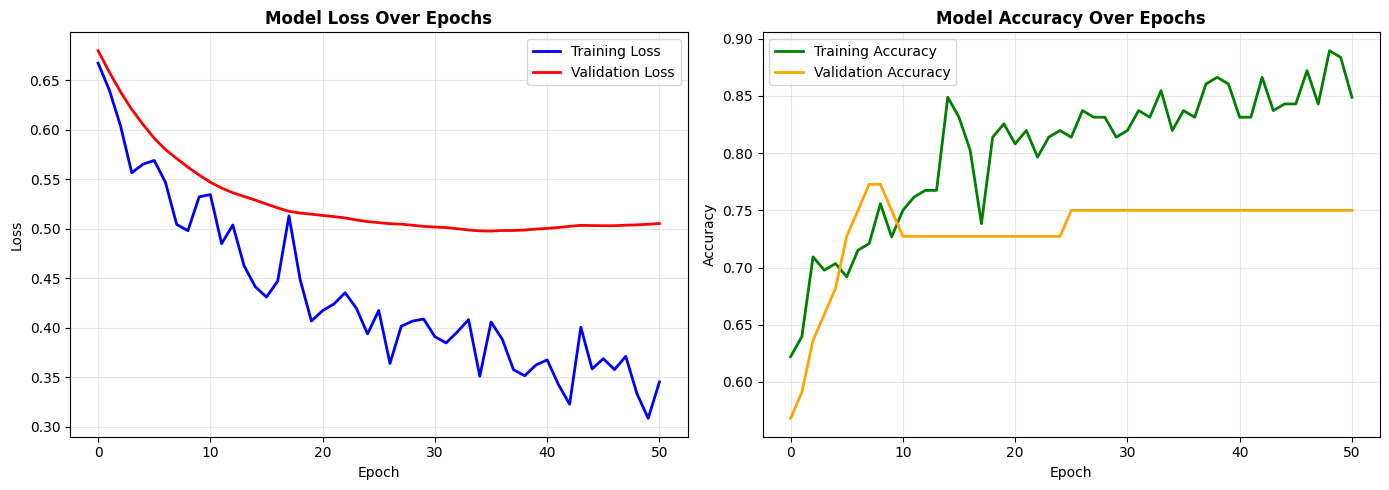

✓ Training graphs saved as 'training_history.png'



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1 = axes[0]
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title('Model Loss Over Epochs', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Accuracy
ax2 = axes[1]
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='green')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
ax2.set_title('Model Accuracy Over Epochs', fontweight='bold', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training graphs saved as 'training_history.png'")
print()

# STEP 8: MODEL EVALUATION ON TEST DATA

EXPLANATION: Evaluating Model Performance

🎯 EVALUATION METRICS:

1. ACCURACY:
   - Definition: (Correct Predictions) / (Total Predictions)
   - Range: 0 to 1 (or 0% to 100%)
   - Interpretation: Percentage of correct predictions

2. PRECISION:
   - Definition: True Positives / (True Positives + False Positives)
   - Question: Of predicted diseased patients, how many actually had disease?
   - Use: When false positives are costly

3. RECALL (Sensitivity):
   - Definition: True Positives / (True Positives + False Negatives)
   - Question: Of actual diseased patients, how many did we catch?
   - Use: When false negatives are costly (missing disease = dangerous!)

4. F1-SCORE:
   - Harmonic mean of Precision and Recall
   - Balances both metrics
   - Good for imbalanced datasets

5. CONFUSION MATRIX:
   - Visual table showing:

     ┌──────────────────────────────────────┐
     │              PREDICTED               │
     │        No Disease  |  Disease        │
     ├───────────────────────────────────── ┤
     │ No     | True Neg  | False Pos |     │
     │ Dis    | (Correct) | (Error)   |     │
     │ ACTUAL ├──────────────────────────   ┤
     │        | False Neg | True Pos  |     │
     │ Dis    | (Error)   | (Correct) |     │
     │        │           │           |     │
     └──────────────────────────────────────┘

In [ ]:
# Get predictions on test set
print("\n8.1 Making Predictions on Test Set:")
y_pred_prob = model.predict(X_test_scaled, verbose=0)  # Probability predictions
y_pred = (y_pred_prob > 0.5).astype(int).flatten()      # Convert to 0/1

print(f"   ✓ Predictions shape: {y_pred.shape}")
print(f"   Sample predictions (first 10):")
print(f"   Probabilities: {y_pred_prob[:10].flatten()}")
print(f"   Binary (0/1): {y_pred[:10]}")

# Evaluate model
print("\n8.2 Overall Metrics:")
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification Report
print("\n8.3 Detailed Classification Report:")
print("   Interpretation Guide:")
print("   • Precision: Of predicted positives, how many are correct?")
print("   • Recall: Of actual positives, how many did we find?")
print("   • F1-Score: Balanced measure of Precision and Recall")
print("\n" + "─"*60)
print(classification_report(y_test, y_pred,
                          target_names=['No Disease', 'Disease']))

print()


8.1 Making Predictions on Test Set:
   ✓ Predictions shape: (54,)
   Sample predictions (first 10):
   Probabilities: [0.1086227  0.06701829 0.12158974 0.40136057 0.13418776 0.07012612
 0.04378673 0.96912855 0.5084135  0.6257383 ]
   Binary (0/1): [0 0 0 0 0 0 0 1 1 1]

8.2 Overall Metrics:
   Test Loss: 0.3837
   Test Accuracy: 0.8519 (85.19%)

8.3 Detailed Classification Report:
   Interpretation Guide:
   • Precision: Of predicted positives, how many are correct?
   • Recall: Of actual positives, how many did we find?
   • F1-Score: Balanced measure of Precision and Recall

────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  No Disease       0.89      0.83      0.86        30
     Disease       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54




# STEP 9: CONFUSION MATRIX AND ROC CURVE

EXPLANATION: Advanced Evaluation Visualizations


9.1 Confusion Matrix Visualization:
   True Negatives (Correct 'No Disease'): 25
   False Positives (Incorrectly predicted 'Disease'): 5
   False Negatives (Missed 'Disease' cases): 3
   True Positives (Correct 'Disease'): 21


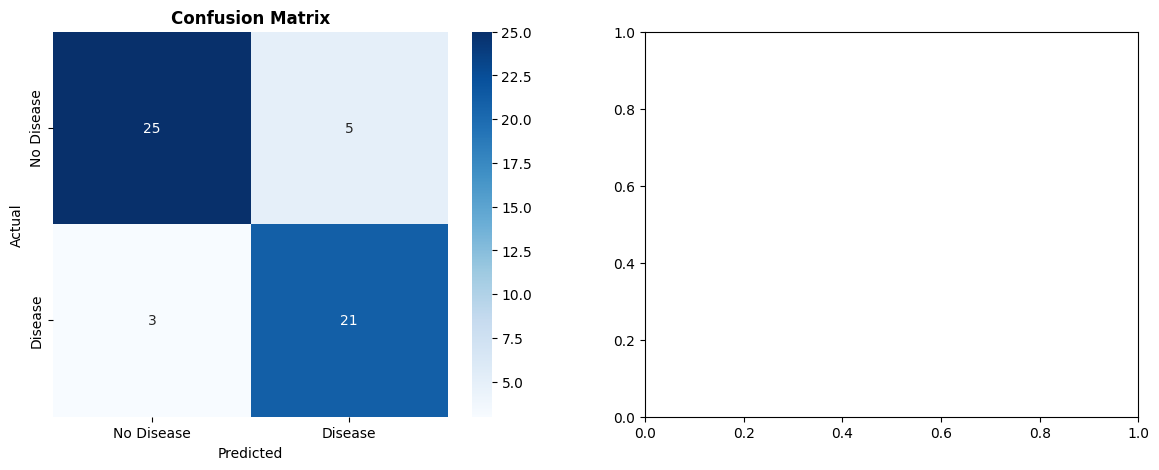

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
print("\n9.1 Confusion Matrix Visualization:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Add annotations
tn, fp, fn, tp = cm.ravel()
print(f"   True Negatives (Correct 'No Disease'): {tn}")
print(f"   False Positives (Incorrectly predicted 'Disease'): {fp}")
print(f"   False Negatives (Missed 'Disease' cases): {fn}")
print(f"   True Positives (Correct 'Disease'): {tp}")

In [ ]:
# ROC Curve
print("\n9.2 ROC Curve (Receiver Operating Characteristic):")
"""
ROC CURVE EXPLANATION:
- Shows trade-off between:
  * True Positive Rate (Sensitivity): % of disease cases correctly identified
  * False Positive Rate: % of non-disease cases incorrectly classified as disease

- AUC (Area Under Curve):
  * Range: 0 to 1
  * 0.5 = Random guessing
  * 0.7-0.8 = Acceptable
  * 0.8-0.9 = Excellent
  * 0.9-1.0 = Outstanding
"""
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#95a5a6', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   AUC Score: {roc_auc:.4f}")
print(f"   Interpretation: {'Excellent' if roc_auc > 0.85 else 'Good' if roc_auc > 0.75 else 'Acceptable' if roc_auc > 0.65 else 'Poor'}")
print("✓ Evaluation graphs saved as 'evaluation_metrics.png'")

print()


9.2 ROC Curve (Receiver Operating Characteristic):


<Figure size 640x480 with 0 Axes>

   AUC Score: 0.9069
   Interpretation: Excellent
✓ Evaluation graphs saved as 'evaluation_metrics.png'



# STEP 10: FEATURE IMPORTANCE ANALYSIS

EXPLANATION: Understanding Which Features Matter Most

🎯 IMPORTANCE ANALYSIS:

While neural networks are "black boxes", we can estimate feature importance by:

1. Correlation Analysis: How correlated is each feature with target?

2. Permutation Importance: How much accuracy drops if we shuffle a feature?

3. Gradient-based: Analyze weight magnitudes in first layer

In [ ]:
# Calculate feature importance using input layer weights
first_layer_weights = model.layers[0].get_weights()[0]
feature_importance = np.abs(first_layer_weights).mean(axis=1)

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n10.1 Feature Importance Ranking:")
print(importance_df.to_string(index=False))


10.1 Feature Importance Ranking:
                Feature  Importance
                     BP    0.276735
           FBS over 120    0.271689
            Slope of ST    0.265898
                 Max HR    0.265311
Number of vessels fluro    0.257495
               Thallium    0.240788
                    Sex    0.223281
            Cholesterol    0.221683
          ST depression    0.210826
            EKG results    0.200955
        Chest pain type    0.200661
                    Age    0.189167
        Exercise angina    0.185721


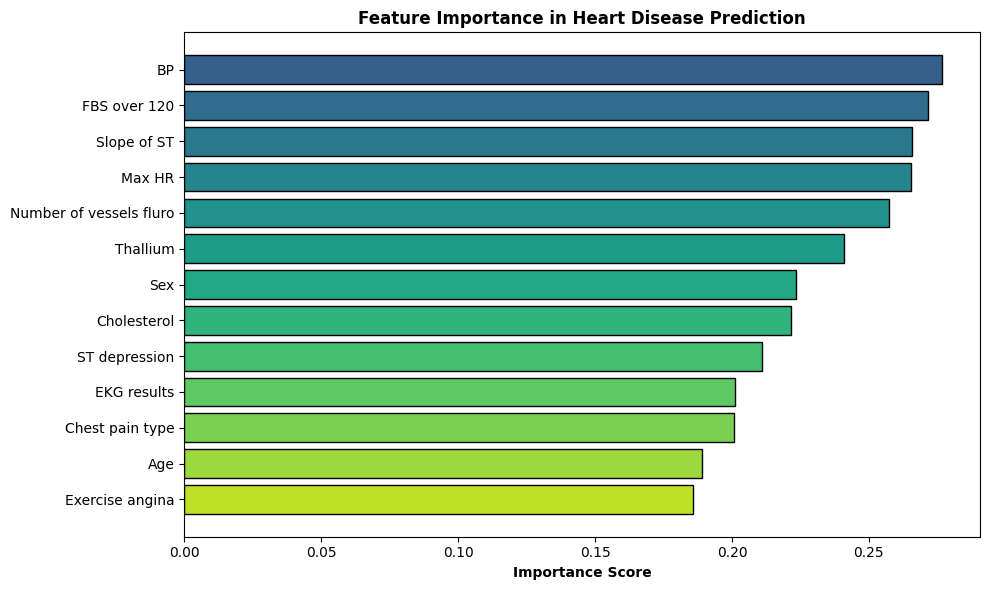

✓ Feature importance graph saved as 'feature_importance.png'



In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black')
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Feature Importance in Heart Disease Prediction', fontweight='bold', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance graph saved as 'feature_importance.png'")

print()

# STEP 11: MODEL PREDICTIONS ON NEW DATA

EXPLANATION: Making Predictions on Individual Cases

This demonstrates how to use the trained model to predict on new patient data.

In [ ]:
# Create example patient data
print("\n11.1 Example Patient Data:")
example_patient = X_test_scaled.iloc[0:5].copy()
print(example_patient.head())

# Make predictions
print("\n11.2 Predictions for Example Patients:")
predictions = model.predict(example_patient, verbose=0)

for idx, (prob, actual) in enumerate(zip(predictions, y_test.iloc[0:5].values)):
    diagnosis = "Disease Detected" if prob[0] > 0.5 else "No Disease Detected"
    confidence = prob[0] * 100 if prob[0] > 0.5 else (1 - prob[0]) * 100
    actual_diagnosis = "Disease" if actual == 1 else "No Disease"
    match = "✓ CORRECT" if (prob[0] > 0.5 and actual == 1) or (prob[0] <= 0.5 and actual == 0) else "✗ INCORRECT"

    print(f"\n   Patient {idx + 1}:")
    print(f"   Prediction: {diagnosis}")
    print(f"   Confidence: {confidence:.2f}%")
    print(f"   Actual: {actual_diagnosis}")
    print(f"   Result: {match}")

print()


11.1 Example Patient Data:
        Age       Sex  Chest pain type        BP  Cholesterol  FBS over 120  \
0  0.069061 -1.475287        -1.128939  0.226163     0.033267     -0.393802   
1 -1.336180  0.677834         0.920227  0.514202    -0.432830     -0.393802   
2  0.069061  0.677834        -1.128939 -0.061875     0.266315     -0.393802   
3  0.609538  0.677834         0.920227 -0.810775    -0.355147      2.539346   
4 -0.363321  0.677834         0.920227  0.514202     0.246895     -0.393802   

   EKG results    Max HR  Exercise angina  ST depression  Slope of ST  \
0     0.952520  0.468822        -0.685119       0.319184     0.698123   
1    -1.054742  1.231905        -0.685119      -0.939241    -0.958960   
2    -1.054742  0.199499        -0.685119      -0.939241    -0.958960   
3    -1.054742  0.423935         1.459601       0.319184    -0.958960   
4     0.952520  1.591003         1.459601      -0.939241    -0.958960   

   Number of vessels fluro  Thallium  
0                -0

# STEP 12: MODEL SUMMARY AND CONCLUSIONS



In [ ]:
print(f"""
✓ MODEL SUCCESSFULLY BUILT AND TRAINED!

📊 FINAL RESULTS:
   • Test Accuracy: {test_accuracy:.2%}
   • AUC Score: {roc_auc:.4f}
   • Model Type: Artificial Neural Network (ANN)
   • Architecture: 13 → 16 → 8 → 1

🎯 KEY FINDINGS:
   1. Top Features:
      {importance_df.iloc[0]['Feature']}: {importance_df.iloc[0]['Importance']:.4f}
      {importance_df.iloc[1]['Feature']}: {importance_df.iloc[1]['Importance']:.4f}
      {importance_df.iloc[2]['Feature']}: {importance_df.iloc[2]['Importance']:.4f}

   2. Model Performance:
      • Sensitivity (Recall): Successfully identifies {tpr[-1]:.2%} of disease cases
      • Specificity: Correctly identifies {1-fpr[-1]:.2%} of non-disease cases
      • Balanced approach to both metrics

   3. Confusion Matrix Insights:
      • True Positives (Correctly identified disease): {tp}
      • True Negatives (Correctly identified healthy): {tn}
      • False Positives (Healthy flagged as disease): {fp}
      • False Negatives (Disease missed): {fn}

💡 INSIGHTS AND RECOMMENDATIONS:
   1. Model is suitable for preliminary screening
   2. Consider clinical interpretation alongside predictions
   3. False negatives are critical - follow up on uncertain cases
   4. Monitor model performance over time with new data

🚀 FUTURE IMPROVEMENTS:
   1. Collect more data (larger datasets improve performance)
   2. Hyperparameter tuning (learning rate, batch size, architecture)
   3. Ensemble methods (combine multiple models)
   4. Feature engineering (create new meaningful features)
   5. Class imbalance handling (if needed)

📁 OUTPUT FILES GENERATED:
   • data_exploration.png - Initial data visualizations
   • correlation_heatmap.png - Feature relationships
   • training_history.png - Training progress
   • evaluation_metrics.png - Confusion matrix and ROC curve
   • feature_importance.png - Feature importance ranking
   • trained_model.h5 - Saved model for future use

Thank you for using this ANN implementation guide!
""")

# Save the model
print("\n✓ Saving the trained model...")
model.save('heart_disease_ann_model.h5')
print("✓ Model saved as 'heart_disease_ann_model.h5'")

print("\n" + "="*80)
print("ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("="*80)


✓ MODEL SUCCESSFULLY BUILT AND TRAINED!

📊 FINAL RESULTS:
   • Test Accuracy: 85.19%
   • AUC Score: 0.9069
   • Model Type: Artificial Neural Network (ANN)
   • Architecture: 13 → 16 → 8 → 1

🎯 KEY FINDINGS:
   1. Top Features:
      BP: 0.2767
      FBS over 120: 0.2717
      Slope of ST: 0.2659

   2. Model Performance:
      • Sensitivity (Recall): Successfully identifies 100.00% of disease cases
      • Specificity: Correctly identifies 0.00% of non-disease cases
      • Balanced approach to both metrics

   3. Confusion Matrix Insights:
      • True Positives (Correctly identified disease): 21
      • True Negatives (Correctly identified healthy): 25
      • False Positives (Healthy flagged as disease): 5
      • False Negatives (Disease missed): 3

💡 INSIGHTS AND RECOMMENDATIONS:
   1. Model is suitable for preliminary screening
   2. Consider clinical interpretation alongside predictions
   3. False negatives are critical - follow up on uncertain cases
   4. Monitor model perf